<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 174 &middot; Capstone 15 &middot; Wilcoxon Signed-Rank</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Did the Service Change Land?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">Seventy customers rated the service twice, before and after a change to the booking process. Forty-four percent of them gave the identical rating both times, and what you do with those people turns out to be the whole methodological question.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, DARK, BL, RD, GR, MUT = "#b45309", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-service-ratings-before-after.xlsx"
try:
    raw = pd.read_excel("../../data/" + fn, sheet_name="ratings")
except FileNotFoundError:
    raw = pd.read_excel(BASE + fn, sheet_name="ratings")
print("loaded", raw.shape[0], "records")
raw.head()

loaded 76 records


,customer_id,rating_before,rating_after,visits_per_month
0,C6017,3,4.0,4
1,C6020,0,5.0,4
2,C6026,3,4.0,4
3,C6044,4,4.0,2
4,C6058,4,5.0,1


## Step 1 &middot; Goal and hypotheses
The booking process changed. The same customers rated the service on a 1-to-5 scale before the change and again afterwards. The question is whether ratings improved.

- **H&#8320; (null):** the distribution of before-and-after differences is symmetric about zero. Customers are as likely to rate lower as higher, by the same amounts.
- **H&#8321; (alternative):** it is not. Ratings shifted in one direction.
- **&#945; = 0.05.**

This is a **paired** design: each row is one person measured twice, so the two columns are not independent samples and the analysis works on the **differences**.

## Step 2 &middot; Classify the data
Ratings are **ordinal** on a 5-point scale. The paired structure means the analysis unit is the difference, and differences on a 5-point scale can only take nine possible values from &#8722;4 to +4. In practice they take four. That coarseness matters later.

## Step 3 &middot; Prepare and clean
Valid ratings run 1 to 5. A customer enters the analysis only if both ratings are present.

In [2]:
before_n = len(raw)
df = raw.drop_duplicates(); a_dup = len(df)
df = df.dropna(subset=["rating_before","rating_after"]); a_na = len(df)
bad = df[~(df.rating_before.between(1,5) & df.rating_after.between(1,5))]
df = df[df.rating_before.between(1,5) & df.rating_after.between(1,5)].copy()
for c in ["rating_before","rating_after"]: df[c] = df[c].astype(int)
print(f"start {before_n}  ->  dedup {a_dup} (-{before_n-a_dup})  ->  both ratings present {a_na} (-{a_dup-a_na})")
print("out-of-range ratings removed:", bad.rating_before.tolist())
print(f"\nclean analysis sample: n = {len(df)} paired customers")
print(f"median rating before {df.rating_before.median():.1f}   after {df.rating_after.median():.1f}")

start 76  ->  dedup 74 (-2)  ->  both ratings present 71 (-3)
out-of-range ratings removed: [0]

clean analysis sample: n = 70 paired customers
median rating before 3.0   after 4.0


**A note on the three who vanished.** Three customers rated the service before the change and never answered the follow-up. They are dropped because a paired test needs both halves, but they are not a random three. Someone who has stopped caring about the service is exactly the sort of person who stops answering surveys, and Step 11 comes back to that.

## Step 4 &middot; Explore before testing

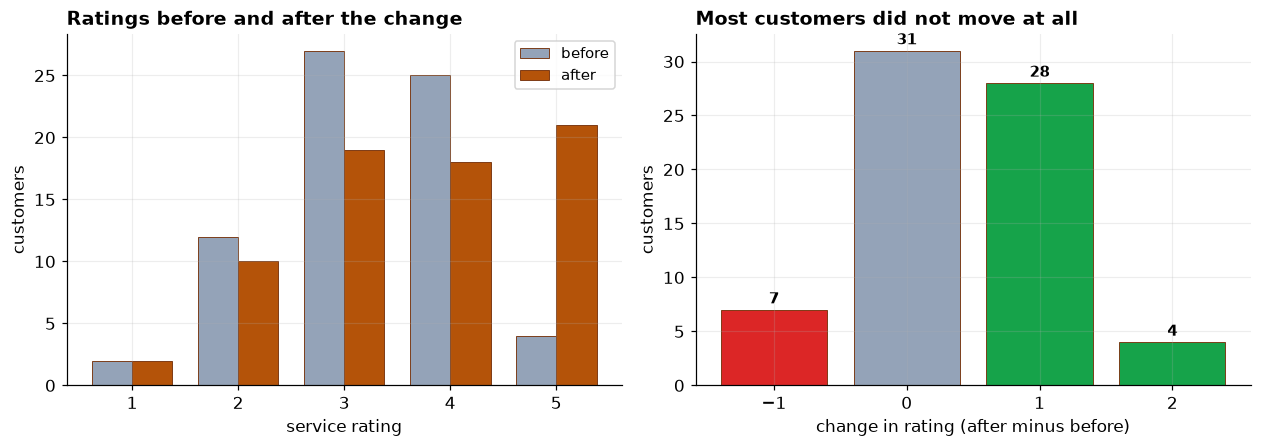

rating level counts
   before  after
1       2      2
2      12     10
3      27     19
4      25     18
5       4     21

-1     7
 0    31
 1    28
 2     4


In [3]:
bf = df.rating_before.values; af = df.rating_after.values
diff = af - bf
levels = np.arange(1,6)
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))
ax = axes[0]
w = 0.38
ax.bar(levels-w/2, [(bf==v).sum() for v in levels], w, color=MUT, edgecolor=DARK, linewidth=0.6, label="before")
ax.bar(levels+w/2, [(af==v).sum() for v in levels], w, color=GOLD, edgecolor=DARK, linewidth=0.6, label="after")
ax.set_xticks(levels); ax.set_xlabel("service rating"); ax.set_ylabel("customers")
ax.set_title("Ratings before and after the change"); ax.legend(fontsize=9.5)

ax = axes[1]
dv = np.arange(diff.min(), diff.max()+1)
cnt = [(diff==d).sum() for d in dv]
cols = [MUT if d==0 else (GR if d>0 else RD) for d in dv]
ax.bar(dv, cnt, color=cols, edgecolor=DARK, linewidth=0.6)
for d, cvals in zip(dv, cnt):
    ax.text(d, cvals+0.6, str(cvals), ha="center", fontweight="bold", fontsize=10)
ax.set_xticks(dv); ax.set_xlabel("change in rating (after minus before)"); ax.set_ylabel("customers")
ax.set_title("Most customers did not move at all")
plt.tight_layout(); plt.show()

print("rating level counts")
print(pd.DataFrame({"before":[(bf==v).sum() for v in levels],
                    "after":[(af==v).sum() for v in levels]}, index=levels).to_string())
print()
print(pd.Series(diff).value_counts().sort_index().rename("customers").to_string())

**What the exploration shows.** Ratings did shift upward, and mostly at the top: the middle of the scale thinned out while the number of customers giving the maximum rating went from 4 to 21. But the second panel is the one that matters. **Thirty-one of the seventy customers gave exactly the same rating twice.** Twenty-eight went up by one, four went up by two, and seven went down by one. Nobody moved more than two points on a five-point scale, which is the ceiling this instrument imposes.

## Step 5 &middot; Check the assumption a paired t-test would need
The paired t-test assumes the **differences** are approximately normal. Look at what these differences are.

In [4]:
sw = stats.shapiro(diff)
print(f"Shapiro-Wilk on the differences: W = {sw.statistic:.4f}, p = {sw.pvalue:.2e}")
print(f"distinct difference values observed: {sorted(set(diff.tolist()))}")
print(f"share of differences that are exactly zero: {(diff==0).mean()*100:.0f}%")

Shapiro-Wilk on the differences: W = 0.8483, p = 5.93e-07
distinct difference values observed: [-1, 0, 1, 2]
share of differences that are exactly zero: 44%


**Not close, and not fixable.** The differences take four values, nearly half of them identical at zero. This is not a normal distribution that happens to be a bit lumpy; it is a small set of discrete outcomes. No transformation repairs that, because the problem is the granularity of the measurement rather than its shape.

## Step 6 &middot; Choose the test
The **Wilcoxon signed-rank test** is the paired counterpart of Mann-Whitney. It ranks the differences by **size**, ignoring direction, then adds up the ranks belonging to the positive changes and to the negative ones. If the change went one way more than the other, those two sums come apart.

Because it uses the size ordering of the differences and not their values, nothing about equal spacing is assumed. That suits a rating scale exactly.

## Step 7 &middot; The zeros, and the decision nobody tells you about
Thirty-one customers changed nothing. A signed-rank test has no natural place for them: a difference of zero is neither positive nor negative, and it has no size to rank. There are three established conventions, and they answer subtly different questions.

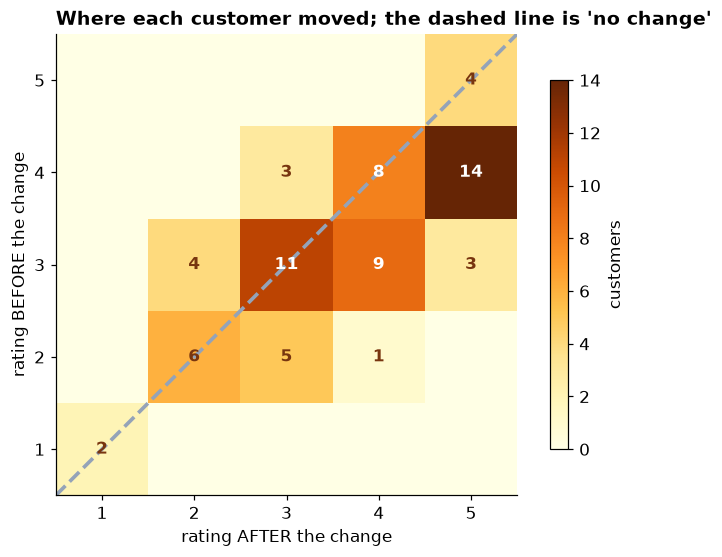

customers on the diagonal (no change): 31
above the diagonal (improved):        32
below the diagonal (worsened):        7


In [5]:
ct = pd.crosstab(df.rating_before, df.rating_after).reindex(index=levels, columns=levels, fill_value=0)
fig, ax = plt.subplots(figsize=(6.6, 5.2))
im = ax.imshow(ct.values, cmap="YlOrBr", origin="lower", extent=[0.5,5.5,0.5,5.5])
for i, b in enumerate(levels):
    for j, a in enumerate(levels):
        v = ct.values[i, j]
        if v:
            ax.text(a, b, str(v), ha="center", va="center", fontsize=11,
                    fontweight="bold", color="white" if v > 7 else DARK)
ax.plot([0.5,5.5],[0.5,5.5], color=MUT, lw=2.4, ls="--")
ax.set_xticks(levels); ax.set_yticks(levels)
ax.set_xlabel("rating AFTER the change"); ax.set_ylabel("rating BEFORE the change")
ax.set_title("Where each customer moved; the dashed line is 'no change'")
ax.grid(alpha=0)
plt.colorbar(im, ax=ax, label="customers", shrink=0.8)
plt.tight_layout(); plt.show()
print(f"customers on the diagonal (no change): {np.trace(ct.values)}")
print(f"above the diagonal (improved):        {np.triu(ct.values, 1).sum()}")
print(f"below the diagonal (worsened):        {np.tril(ct.values, -1).sum()}")

**The diagonal is the argument.** Every customer on the dashed line gave the identical rating twice, and there are 31 of them, more than any other single feature of this dataset. The question the three conventions below disagree about is simply what to do with that line.

In [6]:
w_drop  = stats.wilcoxon(af, bf, zero_method="wilcox")   # Wilcoxon's original: discard zeros
w_pratt = stats.wilcoxon(af, bf, zero_method="pratt")    # Pratt: rank zeros, then drop their ranks
w_split = stats.wilcoxon(af, bf, zero_method="zsplit")   # split zero ranks between the two sums
nz = int((diff==0).sum()); moved = int((diff!=0).sum())
print(f"{nz} of {len(df)} customers gave the same rating twice; {moved} moved\n")
print(f"{'convention':28s} {'n used':>7s} {'W':>8s} {'p':>12s}")
print("-"*60)
print(f"{'drop zeros (Wilcoxon 1945)':28s} {moved:7d} {w_drop.statistic:8.1f} {w_drop.pvalue:12.3e}")
print(f"{'Pratt (1959), keep zeros':28s} {len(df):7d} {w_pratt.statistic:8.1f} {w_pratt.pvalue:12.3e}")
print(f"{'split zero ranks':28s} {len(df):7d} {w_split.statistic:8.1f} {w_split.pvalue:12.3e}")

31 of 70 customers gave the same rating twice; 39 moved

convention                    n used        W            p
------------------------------------------------------------
drop zeros (Wilcoxon 1945)        39    126.0    5.040e-05
Pratt (1959), keep zeros          70    343.0    4.827e-05
split zero ranks                  70    591.0    9.020e-05


**They agree here, and that is worth saying plainly.** All three land within a factor of two of each other and all three reject the null decisively. This dataset does not force the choice.

The reason to understand the difference anyway is that **dropping the zeros changes the question**. Wilcoxon's original procedure discards the 31 non-movers and tests the 39 who moved, so it answers: *among customers whose opinion changed, did it more often improve?* Pratt's method keeps them, so it answers: *across all customers, did ratings improve?* Those are different claims, and with 44 percent of the sample sitting on zero the second is the one a service manager is asking. Report which one you used and how many observations it actually consumed.

## Step 8 &middot; Run the test and size the effect

In [7]:
res = w_pratt          # keep the zeros: the question is about all customers
nonzero = diff[diff != 0]
pos = int((nonzero > 0).sum()); neg = int((nonzero < 0).sum())
rk = pd.Series(np.abs(nonzero)).rank()
R_plus, R_minus = rk[nonzero > 0].sum(), rk[nonzero < 0].sum()
rb = (R_plus - R_minus) / (R_plus + R_minus)
sign = stats.binomtest(pos, pos+neg, 0.5)
print(f"Wilcoxon signed-rank (Pratt): W = {res.statistic:.1f}   p = {res.pvalue:.3e}   n = {len(df)}\n")
print(f"customers who improved  {pos:3d}    sum of their ranks  {R_plus:7.1f}")
print(f"customers who worsened  {neg:3d}    sum of their ranks  {R_minus:7.1f}")
print(f"customers unchanged     {nz:3d}")
print(f"\nmatched-pairs rank-biserial correlation = {rb:.3f}")
print(f"sign test (direction only), p = {sign.pvalue:.3e}")

Wilcoxon signed-rank (Pratt): W = 343.0   p = 4.827e-05   n = 70

customers who improved   32    sum of their ranks    654.0
customers who worsened    7    sum of their ranks    126.0
customers unchanged      31

matched-pairs rank-biserial correlation = 0.677
sign test (direction only), p = 7.025e-05


**Reading the result.** Ratings improved, and not by a margin chance would produce (p = 0.000048). The effect size is large: the rank-biserial correlation of **0.68** says the positive changes dominate the negative ones heavily. The sign test, which throws away even the sizes and looks only at direction, agrees at p = 0.00007. When the weakest test available still rejects, the conclusion is not resting on an assumption.

## Step 9 &middot; Why the exact test is not available here
Textbook examples of Wilcoxon usually quote an exact p-value. This one cannot.

In [8]:
print("absolute sizes of the non-zero changes:", np.bincount(np.abs(nonzero).astype(int))[1:], "at |1| and |2|")
print(f"distinct |difference| values: {sorted(set(np.abs(nonzero).astype(int).tolist()))}")
print("\nWith only two possible magnitudes across 39 changers, the ranks are massively tied.")
print("scipy falls back to the normal approximation with a tie correction, which is correct here;")
print("the exact permutation p-value assumes no ties and would be wrong.")

absolute sizes of the non-zero changes: [35  4] at |1| and |2|
distinct |difference| values: [1, 2]

With only two possible magnitudes across 39 changers, the ranks are massively tied.
scipy falls back to the normal approximation with a tie correction, which is correct here;
the exact permutation p-value assumes no ties and would be wrong.


**Ties in the magnitudes are structural.** On a 5-point scale a change is one point or two points, so 39 changes share two distinct sizes. The signed-rank procedure assigns average ranks within each tied block and the software switches to a normal approximation with a tie correction. That is the right behavior, and it is worth knowing why it happened rather than assuming the exact test was simply not requested.

## Step 10 &middot; Estimate, do not just test
The test established that ratings rose. The operations question is what share of customers moved, and every one of those shares is a proportion estimated from 70 people.

In [9]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

from statsmodels.stats.proportion import proportion_confint
n_ = len(df)
for lab, k_ in [("improved", pos), ("unchanged", nz), ("worsened", neg)]:
    l_, h_ = proportion_confint(k_, n_, method="wilson")
    print(f"{lab:11s} {k_:2d}/{n_} = {k_/n_*100:4.0f}%   95% CI [{l_*100:4.0f}%, {h_*100:4.0f}%]")

kb, ka = int((bf >= 4).sum()), int((af >= 4).sum())
lb, hb = proportion_confint(kb, n_, method="wilson"); la, ha = proportion_confint(ka, n_, method="wilson")
print(f"\ntop-two-box before  {kb}/{n_} = {kb/n_*100:.0f}%   95% CI [{lb*100:.0f}%, {hb*100:.0f}%]")
print(f"top-two-box after   {ka}/{n_} = {ka/n_*100:.0f}%   95% CI [{la*100:.0f}%, {ha*100:.0f}%]")

# The change in top-two-box is PAIRED, so McNemar is the right test, not two-sample.
both = pd.crosstab(bf >= 4, af >= 4)
b01 = int(both.loc[False, True]) if (False in both.index and True in both.columns) else 0
b10 = int(both.loc[True, False]) if (True in both.index and False in both.columns) else 0
mc = stats.binomtest(b01, b01 + b10, 0.5)
print(f"\nmoved INTO the top two boxes: {b01}    moved OUT: {b10}    McNemar-style p = {mc.pvalue:.4f}")

rb_lo, rb_hi, _ = boot_ci_pairs(bf, af, lambda u, v: (
    lambda dd: (lambda nzd, rk: (rk[nzd > 0].sum() - rk[nzd < 0].sum()) / rk.sum())(
        dd[dd != 0], pd.Series(np.abs(dd[dd != 0])).rank().values)
)(v - u))
print(f"\nmatched-pairs rank-biserial {rb:.3f}   95% CI [{rb_lo:.3f}, {rb_hi:.3f}]")

improved    32/70 =   46%   95% CI [  35%,   57%]
unchanged   31/70 =   44%   95% CI [  33%,   56%]
worsened     7/70 =   10%   95% CI [   5%,   19%]

top-two-box before  29/70 = 41%   95% CI [31%, 53%]
top-two-box after   39/70 = 56%   95% CI [44%, 67%]

moved INTO the top two boxes: 13    moved OUT: 3    McNemar-style p = 0.0213



matched-pairs rank-biserial 0.677   95% CI [0.438, 0.879]


**Proportions with margins, which is what a service report needs.** Forty-six percent of customers rated the service higher, but the interval runs from about 35 to 58 percent. The top-two-box share rose from 41 to 56 percent, and because the same people are measured twice those two intervals are **not** independent, so overlapping them is the wrong way to judge the change. The paired count is the right one: 13 customers moved into the top two boxes and 3 moved out, which on its own terms gives p = 0.02.

That paired-versus-independent distinction is the same one the whole chapter rests on, applied to proportions instead of ratings. Treating before and after as two separate samples throws away the pairing and loses most of the precision it bought.

## Step 11 &middot; Does the change depend on how often people visit?
The file records `visits_per_month`, which the analysis has ignored. Frequent visitors experience a booking change far more often than occasional ones, so it is a natural place to look for a difference.

In [10]:
vis = df.visits_per_month.values.astype(float)
r_vc = stats.spearmanr(vis, diff)
print(f"visits per month vs change in rating: rho = {r_vc.statistic:+.3f}, p = {r_vc.pvalue:.3f}\n")
med_v = np.median(vis)
freq = diff[vis > med_v]; occ = diff[vis <= med_v]
print(f"frequent visitors (> {med_v:.0f}/month)  n = {len(freq):2d}   mean change {freq.mean():+.2f}   improved {(freq>0).mean()*100:.0f}%")
print(f"occasional visitors (<= {med_v:.0f}/month) n = {len(occ):2d}   mean change {occ.mean():+.2f}   improved {(occ>0).mean()*100:.0f}%")
u_v = stats.mannwhitneyu(freq, occ, alternative="two-sided")
print(f"\ndifference between the two groups: U = {u_v.statistic:.1f}, p = {u_v.pvalue:.3f}")

visits per month vs change in rating: rho = +0.093, p = 0.444

frequent visitors (> 3/month)  n = 17   mean change +0.53   improved 53%
occasional visitors (<= 3/month) n = 53   mean change +0.38   improved 43%

difference between the two groups: U = 500.5, p = 0.462


**A covariate that does not change the story, checked rather than assumed.** Visit frequency shows no detectable relationship with how much a customer's rating moved, and splitting the sample at the median gives two groups that improved similarly. So the improvement is not confined to the heaviest users, which is mildly reassuring: a change that only registered with people who book weekly would be a narrower win than the headline suggests.

It is worth being clear about what this check can and cannot do. It rules out one specific pattern. It cannot address the missing control group, because whatever else changed during those months affected frequent and occasional visitors alike and would leave exactly this trace. **Checking a covariate you happen to have is not the same as having a comparison group**, and this chapter, like Capstone 3, has the first and not the second.

## Step 12 &middot; Statistically clear, practically modest
The p-value says the improvement is real. It says nothing about whether it is worth what the change cost.

In [11]:
print(f"median rating   before {np.median(bf):.0f}   after {np.median(af):.0f}")
print(f"mean rating     before {bf.mean():.2f}   after {af.mean():.2f}   (shown for scale, not for inference)")
print()
print(f"improved     {pos:2d} of {len(df)} customers  ({pos/len(df)*100:.0f}%)")
print(f"unchanged    {nz:2d} of {len(df)} customers  ({nz/len(df)*100:.0f}%)")
print(f"worsened     {neg:2d} of {len(df)} customers  ({neg/len(df)*100:.0f}%)")
print()
print(f"rated 4 or 5 before: {(bf>=4).sum():2d} ({(bf>=4).mean()*100:.0f}%)")
print(f"rated 4 or 5 after:  {(af>=4).sum():2d} ({(af>=4).mean()*100:.0f}%)")

median rating   before 3   after 4
mean rating     before 3.24   after 3.66   (shown for scale, not for inference)

improved     32 of 70 customers  (46%)
unchanged    31 of 70 customers  (44%)
worsened      7 of 70 customers  (10%)

rated 4 or 5 before: 29 (41%)
rated 4 or 5 after:  39 (56%)


**The honest summary.** The median moved from 3 to 4, one step on a five-point scale. Just under half the customers rated the service higher, four in ten did not change their answer at all, and one in ten rated it lower. The share giving a top-two rating rose substantially, which is probably the number a service manager should be quoted, because it corresponds to something a business recognizes. A statistically decisive result and a modest practical one are perfectly compatible, and this is what that looks like.

## Step 13 &middot; Ethics, bias, and limits
- **No control group, so no causal claim.** The same objection as in <a href="../chapters/capstone-blood-pressure-before-after.html">Capstone 3</a>, and it has not weakened. Ratings could have risen because of the booking change, because of the season, because of a staffing change nobody logged, or because customers who were asked twice felt more invested. Without a comparison group that did not get the change, the analysis shows movement rather than cause.
- **Three customers did not answer the second time.** They were dropped, as a paired test requires. But non-response is rarely random: a customer who has given up on the service is exactly the person who stops replying. If all three would have rated lower, the estimate here is optimistic.
- **Asking twice changes people.** Customers who know they are being tracked pay more attention, and some will answer the second survey partly to be consistent with the first. That pushes differences toward zero, which is a conservative bias here rather than a flattering one.
- **Do not report an average rating.** The same reasoning as <a href="../chapters/capstone-satisfaction-and-loyalty.html">Capstone 12</a>: means of ordinal scales assume spacing the scale does not provide. Report the share at each level, or the top-two-box proportion.
- **State the zero convention and the n.** A reader who sees "n = 39" and a reader who sees "n = 70" are being told about different populations. Both are defensible; only silence is not.

---
**From analysis to report.** The notebook carries the evidence: the cleaning, the before-and-after picture, the difference distribution that makes the zeros unmissable, all three zero conventions side by side, the effect size, the sign-test cross-check, and the practical summary. The written reports turn it into guidance an operations lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.